Dataset de Estudiantes
    Horas_estudio  Notas examen
0        4.370861     56.161011
1        9.556429     93.909809
2        7.587945     75.987552
3        6.387926     66.266040
4        2.404168     56.753250
5        2.403951     48.294823
6        1.522753     44.474156
7        8.795585     80.649771
8        6.410035     70.738297
9        7.372653     79.790532
10       1.185260     36.356595
11       9.729189     95.253622
12       8.491984     82.948709
13       2.911052     51.007843
14       2.636425     47.810015
15       2.650641     60.165234
16       3.738180     57.361595
17       5.722808     64.048293
18       4.887505     68.437756
19       3.621062     50.622155
Ecuacion del modelo aprendido
Nota=35.10+5.71*horas_estudio


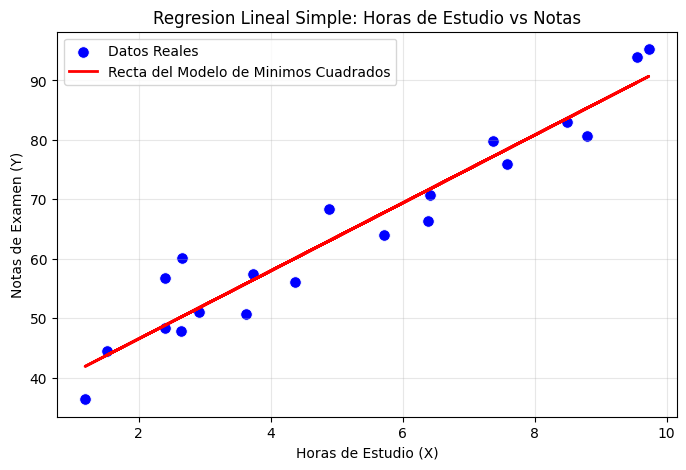

In [ ]:
import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

#set horas de estudio vs notas de examen
np.random.seed(42)
#el uniform nos genera valores decimales,1 - limite minimo, 10 limite maximo, 20 cantidad de calores que se generaran
horas=np.random.uniform(1,10,20)
#35 nota base por cada hora de estudio que relize la nota va a umentar en 6 puntos y a eso le vamos a sumar una variacion aleatoria 
#0 media de error, 5 la std y 20 de cantidad de variaciones q me va a generar 
notas=35+(6*horas)+np.random.normal(0,5,20)
#clip va a limitar los valores el arreglo de notas, para que las notas eesten entre 0 y 100 
notas=np.clip(notas,0,100)

#con este conjunto se entrenar el modelo
df_estudio=pd.DataFrame({
    
    'Horas_estudio':horas,
    'Notas examen':notas,
    
})

print("Dataset de Estudiantes")
print(df_estudio)

#Entrenar el modelo (minimo cuadrado ordinario)

#variable predictora o independiente, q tiene la caracteristica que va autilizar el modelo que va hacer la prediccion, 
# 2 corchete porque skelearn necesita que la variable predictora sea un arreglo bidimensional
X=df_estudio[['Horas_estudio']]
#variable objetivo
y=df_estudio['Notas examen']

#crea un modelo vacio de regresion lineal, osea vacio q  todavia no a aprendido la relacion entre esas 2 variables
modelo=LinearRegression()
#aqui empieza analizar los datos y aprender la relacion entre las 2 variables, es decir,
#va a aprender la pendiente y el intercepto de la recta que mejor se ajusta a los datos
modelo.fit(X,y)

#luego el modelo ya entrenado me va a devolver beta_0 y el beta_1 que es el intercepto y el coeficiente, y teniendo estos 2 
# puedo generar  puedo generar ya la formula de la regresion lineal

#lo que tengo en beta_0 es la nota estimaada cuando las horas de estudio sean 0 
beta_0=modelo.intercept_# -> pendiente
#lo q me devuelve es un arreglo q va a tener todos los coeficientes de todas las variables independientes en este caso solo se le mando 1 variable independiente 
#que son las horas de estudio
beta_1=modelo.coef_[0] # -> pendiente: cuanto va a aumentar la nota estimada por cada hora adicional de estudio 

#crear la ecuacion del modelo
print("Ecuacion del modelo aprendido")
print(f"Nota={beta_0:.2f}+{beta_1:.2f}*horas_estudio")

#visualizacion de la recta
plt.figure(figsize=(8,5))
sns.scatterplot(
    
    data=df_estudio,
    x='Horas_estudio',
    y='Notas examen',
    color='blue',
    s=70,
    label='Datos Reales'
    
)


plt.plot(
    
    df_estudio['Horas_estudio'],
    modelo.predict(X),#calcular la nota estimada del modelo
    color='red',
    linewidth=2,
    label='Recta del Modelo de Minimos Cuadrados'
    
)

plt.title('Regresion Lineal Simple: Horas de Estudio vs Notas')
plt.xlabel('Horas de Estudio (X)')
plt.ylabel('Notas de Examen (Y)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

*35.10 es la nota que puede tener una persona cuando tiene 0 horas de estudio eso es lo que el modelo determino*


*5.71 es lo que puede subir por cada hora de estudio q esta persona tenga esa es la pendiente*
